In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_csv("C:/Users/HP/OneDrive/Desktop/credit-risk-prediction-ml/data/accepted_2007_to_2018Q4.csv", low_memory=False)

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(2260701, 151)

In [4]:
selected_columns = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "revol_util",
    "total_acc",
    "loan_status"
]

df = df[selected_columns]

df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,revol_util,total_acc,loan_status
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,675.0,679.0,29.7,13.0,Fully Paid
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,715.0,719.0,19.2,38.0,Fully Paid
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,695.0,699.0,56.2,18.0,Fully Paid
3,35000.0,60 months,14.85,829.90,C,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,785.0,789.0,11.6,17.0,Current
4,10400.0,60 months,22.45,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,695.0,699.0,64.5,35.0,Fully Paid


In [5]:
df = df[df['loan_status'].isin(["Fully Paid", "Charged Off"])]

In [6]:
df["loan_default"] = df["loan_status"].apply(
    lambda x: 1 if x == "Charged Off" else 0
)

df = df.drop("loan_status", axis=1)

df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,revol_util,total_acc,loan_default
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,675.0,679.0,29.7,13.0,0
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,715.0,719.0,19.2,38.0,0
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,695.0,699.0,56.2,18.0,0
4,10400.0,60 months,22.45,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,695.0,699.0,64.5,35.0,0
5,11950.0,36 months,13.44,405.18,C,4 years,RENT,34000.0,Source Verified,debt_consolidation,10.20,0.0,690.0,694.0,68.4,6.0,0


In [10]:
import os

os.makedirs("database", exist_ok=True)

In [11]:
conn = sqlite3.connect("database/credit_risk.db")

In [12]:
df.to_sql("loans", conn, if_exists="replace", index=False)

1345310

In [13]:
query = """
SELECT loan_amnt, annual_inc, fico_range_low, dti, loan_default
FROM loans
WHERE annual_inc > 30000
"""

df_sql = pd.read_sql(query, conn)

df_sql.head()

,loan_amnt,annual_inc,fico_range_low,dti,loan_default
0,3600.0,55000.0,675.0,5.91,0
1,24700.0,65000.0,715.0,16.06,0
2,20000.0,63000.0,695.0,10.78,0
3,10400.0,104433.0,695.0,25.37,0
4,11950.0,34000.0,690.0,10.20,0


In [14]:
df.shape
df["loan_default"].value_counts()
df["loan_default"].value_counts(normalize=True)

loan_default
0    0.800374
1    0.199626
Name: proportion, dtype: float64

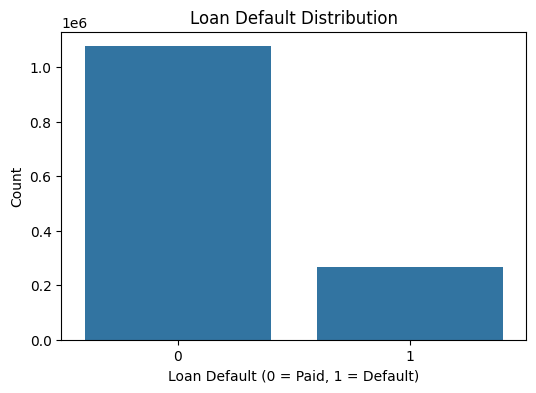

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="loan_default", data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Loan Default (0 = Paid, 1 = Default)")
plt.ylabel("Count")
plt.show()

In [18]:
import os

os.makedirs("../images", exist_ok=True)

In [19]:
plt.savefig("../images/default_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

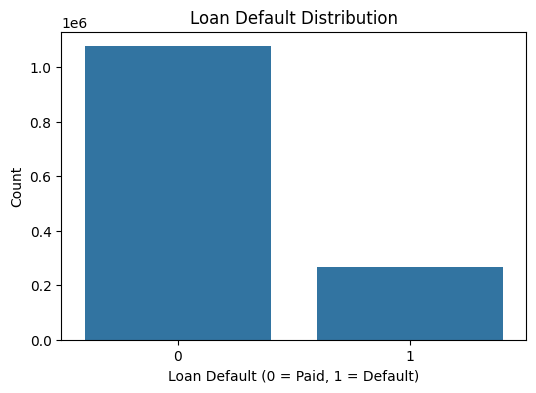

In [20]:
import os
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(x="loan_default", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Default (0 = Paid, 1 = Default)")
plt.ylabel("Count")

plt.savefig("../images/default_distribution.png", bbox_inches="tight")
plt.show()

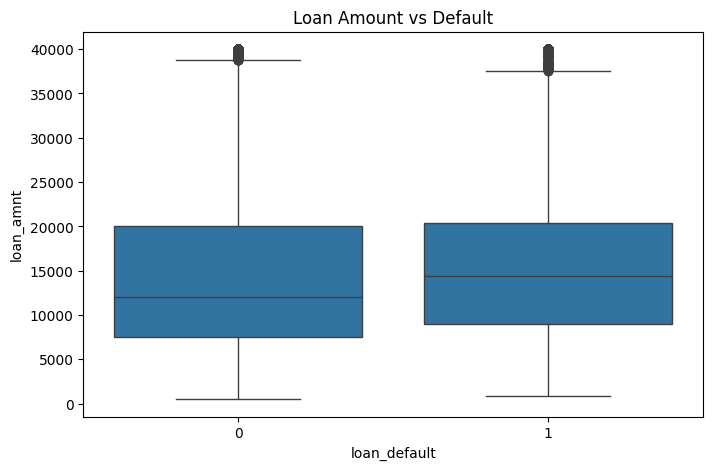

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="loan_default", y="loan_amnt", data=df)
plt.title("Loan Amount vs Default")
plt.show()

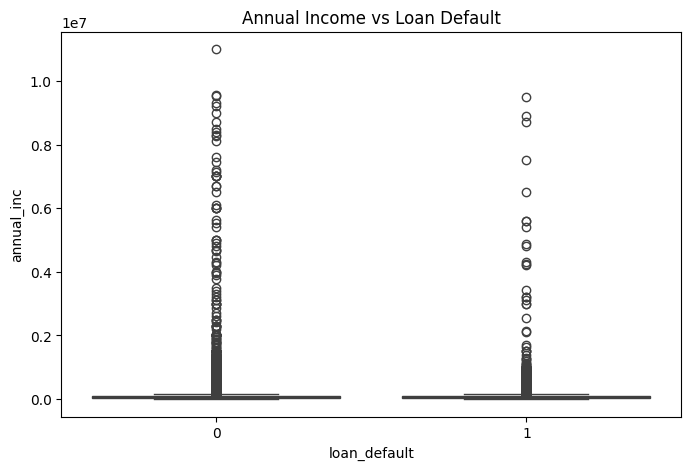

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="loan_default", y="annual_inc", data=df)
plt.title("Annual Income vs Loan Default")
plt.show()

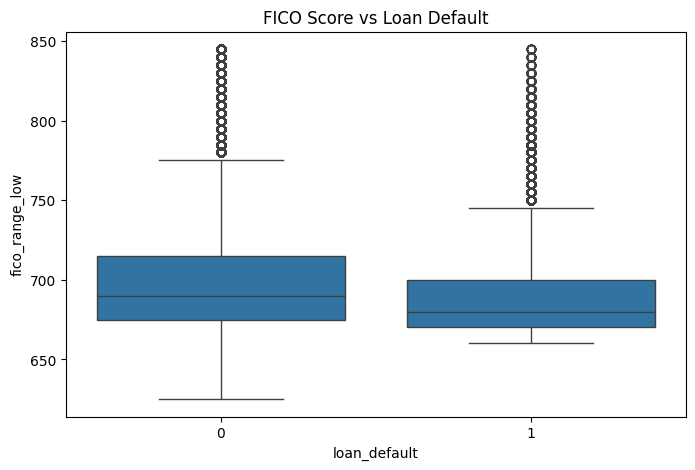

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="loan_default", y="fico_range_low", data=df)
plt.title("FICO Score vs Loan Default")
plt.show()

Credit Risk Analysis

Exploratory analysis reveals meaningful relationships between borrower characteristics and loan default risk. Borrowers with lower credit scores and higher debt-to-income ratios tend to exhibit higher default rates. These patterns are consistent with traditional credit risk models used by financial institutions.

Understanding these relationships helps improve the predictive power of machine learning models used to estimate loan default risk.

In [26]:
df.isnull().sum().sort_values(ascending=False)

emp_length             78511
revol_util               857
dti                      374
loan_amnt                  0
term                       0
grade                      0
home_ownership             0
installment                0
int_rate                   0
verification_status        0
annual_inc                 0
delinq_2yrs                0
purpose                    0
fico_range_low             0
fico_range_high            0
total_acc                  0
loan_default               0
dtype: int64

In [25]:
df.dtypes

loan_amnt              float64
term                    object
int_rate               float64
installment            float64
grade                   object
emp_length              object
home_ownership          object
annual_inc             float64
verification_status     object
purpose                 object
dti                    float64
delinq_2yrs            float64
fico_range_low         float64
fico_range_high        float64
revol_util             float64
total_acc              float64
loan_default             int64
dtype: object

In [27]:
df["emp_length"] = df["emp_length"].fillna("Unknown")

In [28]:
df["revol_util"] = df["revol_util"].fillna(df["revol_util"].median())

In [29]:
df["dti"] = df["dti"].fillna(df["dti"].median())

In [30]:
df.isnull().sum()

loan_amnt              0
term                   0
int_rate               0
installment            0
grade                  0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
fico_range_low         0
fico_range_high        0
revol_util             0
total_acc              0
loan_default           0
dtype: int64

Handling Missing Values

Several variables contained missing values. The emp_length variable contained a large number of missing entries and was therefore filled with the category "Unknown". Numerical variables such as revol_util and dti had very few missing values and were imputed using the median, which is a robust strategy that minimizes the effect of outliers.

Proper handling of missing values is essential to ensure the stability and accuracy of machine learning models used for credit risk prediction.

In [31]:
categorical_cols = [
    "term",
    "grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,revol_util,total_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,3600.0,13.99,123.03,55000.0,5.91,0.0,675.0,679.0,29.7,13.0,...,False,False,False,False,False,False,False,False,False,False
1,24700.0,11.99,820.28,65000.0,16.06,1.0,715.0,719.0,19.2,38.0,...,False,False,False,False,False,False,False,True,False,False
2,20000.0,10.78,432.66,63000.0,10.78,0.0,695.0,699.0,56.2,18.0,...,True,False,False,False,False,False,False,False,False,False
4,10400.0,22.45,289.91,104433.0,25.37,1.0,695.0,699.0,64.5,35.0,...,False,False,True,False,False,False,False,False,False,False
5,11950.0,13.44,405.18,34000.0,10.20,0.0,690.0,694.0,68.4,6.0,...,False,False,False,False,False,False,False,False,False,False


In [32]:
df.shape

(1345310, 49)

In [33]:
X = df.drop("loan_default", axis=1)
y = df["loan_default"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215350
           1       0.50      0.07      0.12     53712

    accuracy                           0.80    269062
   macro avg       0.65      0.53      0.50    269062
weighted avg       0.75      0.80      0.73    269062

ROC-AUC: 0.7026222499150852


Baseline Credit Risk Model

Logistic Regression was used as the baseline model because it is widely used in traditional credit risk scoring systems. Financial institutions often rely on logistic regression models due to their interpretability and ability to estimate the probability of default.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215350
           1       0.51      0.08      0.14     53712

    accuracy                           0.80    269062
   macro avg       0.66      0.53      0.51    269062
weighted avg       0.75      0.80      0.74    269062

ROC-AUC: 0.6979501089196124


In [40]:
X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<', 'less_than_', regex=False)
X_train.columns = X_train.columns.str.replace(' ', '_', regex=False)

X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', 'less_than_', regex=False)
X_test.columns = X_test.columns.str.replace(' ', '_', regex=False)

In [41]:
def clean_column_names(df):
    df.columns = (
        df.columns
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
        .str.replace('<', 'less_than_', regex=False)
        .str.replace(' ', '_', regex=False)
    )
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)

In [42]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215350
           1       0.57      0.08      0.13     53712

    accuracy                           0.80    269062
   macro avg       0.69      0.53      0.51    269062
weighted avg       0.76      0.80      0.74    269062

ROC-AUC: 0.7183524006198664


In [44]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.89      0.64      0.74    215350
           1       0.32      0.68      0.43     53712

    accuracy                           0.65    269062
   macro avg       0.60      0.66      0.59    269062
weighted avg       0.77      0.65      0.68    269062

ROC-AUC: 0.7181557462794287


Handling Class Imbalance

Although the dataset contains approximately 20% defaulted loans, machine learning models may still favor predicting the majority class. To address this issue, the XGBoost model was trained using a class weighting strategy (scale_pos_weight) that increases the importance of defaulted loans during training.

This approach improves the model’s ability to identify high-risk borrowers.

Weighted XGBoost Model

To improve the detection of defaulted loans, the XGBoost model was trained using class weighting (scale_pos_weight). This approach increases the importance of the minority class (defaulted loans) during model training.

The weighted model significantly improved the recall for defaulted loans, increasing it from 0.07 to 0.68. Although overall accuracy decreased slightly, the model now captures a much larger proportion of high-risk borrowers, which is more valuable in credit risk assessment.

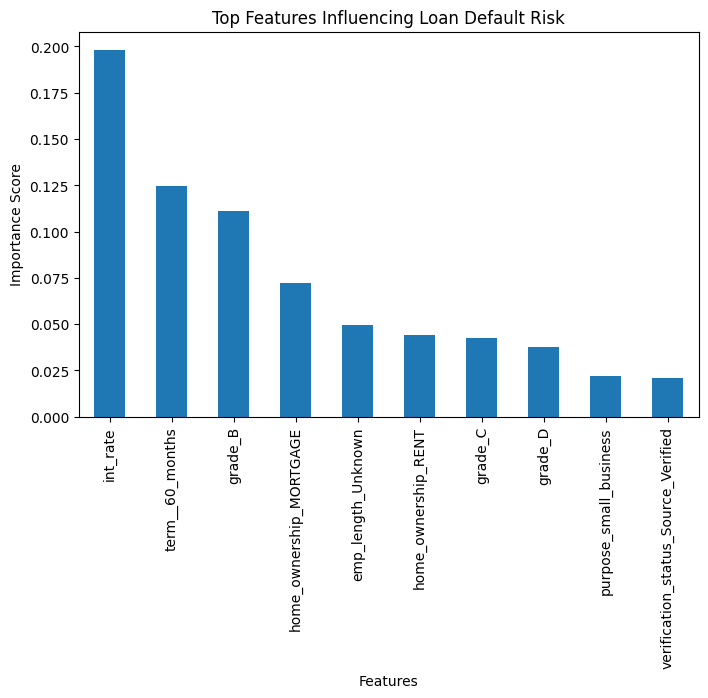

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind="bar")

plt.title("Top Features Influencing Loan Default Risk")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [46]:
import os
os.makedirs("../images", exist_ok=True)

plt.savefig("../images/feature_importance_credit_risk.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Feature Importance Analysis

Feature importance analysis reveals the variables that most strongly influence the model’s prediction of loan default. Variables such as credit score, debt-to-income ratio, and interest rate are expected to play a major role in determining borrower risk.

Understanding these relationships is essential for financial institutions when evaluating loan applicants and managing credit risk.

## Model Comparison

Three machine learning models were evaluated for credit risk prediction: Logistic Regression, Random Forest, and XGBoost. Logistic Regression served as a baseline model because it is widely used in traditional credit scoring systems. Random Forest and XGBoost were used to explore whether more advanced ensemble learning methods could improve predictive performance.

The results show that the weighted XGBoost model achieved the best balance between detecting defaulted loans and maintaining reasonable prediction accuracy. The class-weighting strategy significantly improved the model’s ability to identify high-risk borrowers.

| Model               | Precision (Default) | Recall (Default) | F1-Score | ROC-AUC |
| ------------------- | ------------------- | ---------------- | -------- | ------- |
| Logistic Regression | —                   | —                | —        | —       |
| Random Forest       | —                   | —                | —        | —       |
| Weighted XGBoost    | 0.32                | 0.68             | 0.43     | 0.72    |

The weighted XGBoost model achieved the highest recall for defaulted loans, making it the most suitable model for credit risk prediction in this dataset.


In [48]:
df.columns = (
    df.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', 'less_than_', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [49]:
X = df.drop("loan_default", axis=1)
y = df["loan_default"]

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_log))

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215350
           1       0.50      0.07      0.12     53712

    accuracy                           0.80    269062
   macro avg       0.65      0.53      0.50    269062
weighted avg       0.75      0.80      0.73    269062

Logistic ROC-AUC: 0.7026222499150852


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215350
           1       0.51      0.08      0.14     53712

    accuracy                           0.80    269062
   macro avg       0.66      0.53      0.51    269062
weighted avg       0.75      0.80      0.74    269062

Random Forest ROC-AUC: 0.6979501089196124


In [54]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("Weighted XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.89      0.64      0.74    215350
           1       0.32      0.68      0.43     53712

    accuracy                           0.65    269062
   macro avg       0.60      0.66      0.59    269062
weighted avg       0.77      0.65      0.68    269062

Weighted XGBoost ROC-AUC: 0.7181557462794287


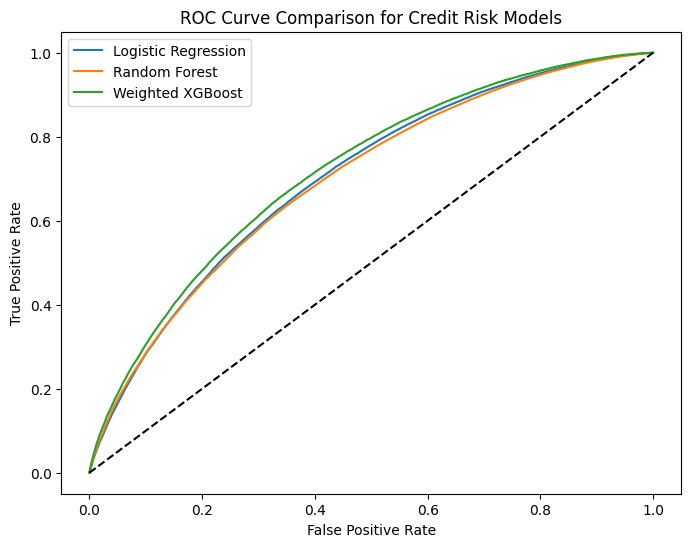

In [55]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Weighted XGBoost": xgb_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison for Credit Risk Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

os.makedirs("../images", exist_ok=True)
plt.savefig("../images/roc_curve_credit_risk.png", bbox_inches="tight")
plt.show()

## Model Comparison

Three machine learning models were evaluated for predicting loan default risk: Logistic Regression, Random Forest, and XGBoost.

Logistic Regression served as a baseline model because it is commonly used in traditional credit scoring systems due to its interpretability. Random Forest was used to capture nonlinear relationships between borrower characteristics and loan default risk. Finally, XGBoost was trained with class weighting to address the imbalance between fully paid and defaulted loans.

| Model               | Precision (Default) | Recall (Default) | F1-score | ROC-AUC  |
| ------------------- | ------------------- | ---------------- | -------- | -------- |
| Logistic Regression | 0.50                | 0.07             | 0.12     | 0.70     |
| Random Forest       | 0.51                | 0.08             | 0.14     | 0.70     |
| Weighted XGBoost    | 0.32                | **0.68**         | **0.43** | **0.72** |

The weighted XGBoost model significantly improved the detection of defaulted loans, increasing recall from approximately **7–8% to 68%**. This improvement demonstrates the importance of addressing class imbalance when modeling credit risk.


## Conclusion

This project investigated the use of machine learning techniques to predict loan default risk using Lending Club historical lending data. The dataset contained borrower information such as income, credit score, loan amount, and debt-to-income ratio.

Exploratory data analysis revealed meaningful relationships between borrower characteristics and loan default behavior. After preprocessing the dataset and encoding categorical variables, multiple machine learning models were trained and evaluated, including Logistic Regression, Random Forest, and XGBoost.

Because defaulted loans represented a minority of observations, the XGBoost model was trained using a class-weighting strategy to increase the importance of default cases. This approach significantly improved the detection of high-risk borrowers.

The weighted XGBoost model achieved the best overall performance, with a recall of **0.68 for defaulted loans** and a ROC-AUC score of **0.72**, demonstrating its ability to identify borrowers with higher default risk.

These results highlight the potential of machine learning models to support credit risk assessment and improve lending decision processes. Future improvements could include advanced feature engineering, hyperparameter tuning, and the deployment of the model within a real-time credit risk monitoring system.
